# Classificação da Qualidade de Vinhos com Machine Learning

## 1. Introdução e contexto do problema

A indústria vitivinícola utiliza tradicionalmente avaliações sensoriais realizadas por especialistas para definir a qualidade de um vinho. Embora esse processo seja importante, ele pode ser subjetivo, demorado e dependente da experiência dos avaliadores.

Neste projeto, o objetivo é utilizar dados físico-químicos dos vinhos para desenvolver modelos de Machine Learning capazes de classificar se um vinho possui alta qualidade ou baixa/média qualidade.

A base utilizada contém variáveis como acidez, teor alcoólico, densidade, pH, sulfatos, dióxido de enxofre e nota de qualidade atribuída ao vinho.

Para simplificar o problema, a variável `quality` será transformada em uma variável binária:

- `1`: vinho de alta qualidade, quando `quality >= 7`;
- `0`: vinho de baixa ou média qualidade, quando `quality < 7`.

Ao final, serão treinados e comparados modelos de classificação para identificar qual deles apresenta melhor desempenho na previsão da qualidade dos vinhos.

## 2. Importação das bibliotecas

Nesta seção, serão importadas as bibliotecas necessárias para manipulação dos dados, visualização gráfica, pré-processamento, treinamento dos modelos e avaliação dos resultados.

As principais bibliotecas utilizadas serão:

- `pandas` e `numpy` para manipulação dos dados;
- `matplotlib` e `seaborn` para visualizações;
- `scikit-learn` para divisão da base, criação dos modelos, pipelines e métricas de avaliação.

In [3]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Separação treino/teste
from sklearn.model_selection import train_test_split, cross_val_score

# Pré-processamento
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Ignorar avisos
import warnings
warnings.filterwarnings("ignore")

## 3. Importação da base de dados

Nesta etapa, será feita a importação do arquivo `WineQT.csv` para o Google Colab.

O arquivo pode ser carregado diretamente do computador usando a função `files.upload()`.

Após o upload, a base será lida com `pandas` e armazenada em um DataFrame chamado `df`.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving WineQT.csv to WineQT.csv


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Tech Challenge - FIAP/Desafio 2 - Vinho/WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 4. Compreensão inicial dos dados

Nesta seção, será feita uma primeira análise da estrutura da base.

Serão verificados:

- quantidade de linhas e colunas;
- nomes das variáveis;
- tipos de dados;
- existência de valores nulos;
- estatísticas descritivas das variáveis numéricas.

Essa etapa ajuda a entender a qualidade da base e identificar possíveis necessidades de tratamento antes da modelagem.

In [5]:
# Quantidade de linhas e colunas
df.shape

(1143, 13)

In [6]:
# Visualização das primeiras linhas
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [7]:
# Informações gerais da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [8]:
# Verificação de valores nulos
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [9]:
# Estatísticas descritivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


### Resumo da compreensão inicial

A base foi carregada corretamente e contém informações físico-químicas dos vinhos, além da variável `quality`, que representa a nota atribuída por especialistas.

Nesta etapa, também foi verificado se existem valores ausentes e qual é o comportamento estatístico inicial das variáveis, como média, desvio-padrão, valores mínimos e máximos.

A coluna `Id` será analisada, mas não será utilizada no treinamento dos modelos, pois representa apenas um identificador da amostra e não uma característica físico-química do vinho.

## 5. Criação da variável alvo binária

O desafio propõe transformar a variável `quality` em uma classificação binária.

A regra adotada será:

- Vinhos com nota maior ou igual a 7 serão classificados como alta qualidade;
- Vinhos com nota menor que 7 serão classificados como baixa ou média qualidade.

Será criada uma nova coluna chamada `high_quality`, onde:

- `1` representa vinho de alta qualidade;
- `0` representa vinho de baixa ou média qualidade.

In [10]:
df["high_quality"] = np.where(df["quality"] >= 7, 1, 0)

df[["quality", "high_quality"]].head(10)

,quality,high_quality
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0


In [11]:
# Distribuição absoluta da nova variável alvo
df["high_quality"].value_counts()

,count
high_quality,
0,984
1,159


In [12]:
# Distribuição percentual da nova variável alvo
df["high_quality"].value_counts(normalize=True) * 100

,proportion
high_quality,
0,86.089239
1,13.910761


### Resumo da criação da variável alvo

A variável `quality` foi transformada em uma variável binária chamada `high_quality`.

Essa transformação permite tratar o problema como uma classificação binária, na qual o modelo deve prever se um vinho pertence ou não ao grupo de alta qualidade.

Essa etapa é essencial, pois define claramente a variável que será prevista pelos modelos de Machine Learning.

## 6. Análise exploratória de dados

Nesta seção, será realizada a análise exploratória dos dados, também conhecida como EDA.

O objetivo é entender melhor o comportamento das variáveis e identificar padrões relevantes.

Serão analisados:

- distribuição da nota original de qualidade;
- distribuição da variável binária criada;
- distribuição das variáveis físico-químicas;
- comparação de algumas variáveis com a classe de qualidade do vinho.

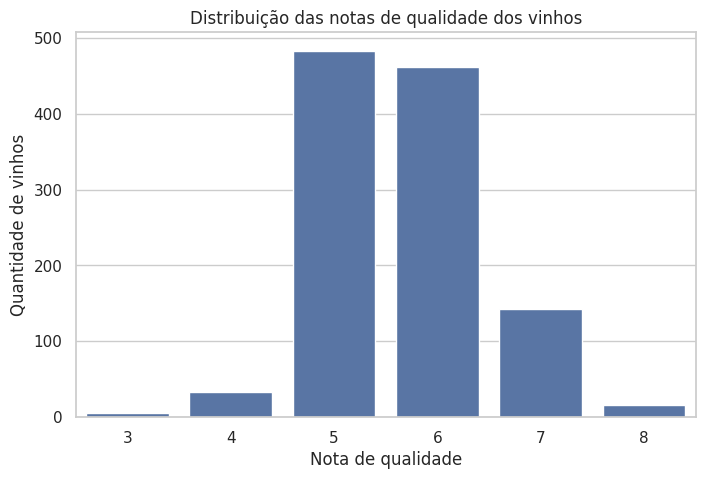

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="quality")
plt.title("Distribuição das notas de qualidade dos vinhos")
plt.xlabel("Nota de qualidade")
plt.ylabel("Quantidade de vinhos")
plt.show()

### Interpretação da distribuição da qualidade

A análise da variável `quality` permite entender como as notas dos vinhos estão distribuídas na base original.

Essa visualização ajuda a identificar se existem muitas amostras em todas as notas ou se a base está concentrada em determinados níveis de qualidade.

Normalmente, espera-se observar maior concentração em notas intermediárias, como 5 e 6, e menor quantidade de vinhos nas notas extremas.

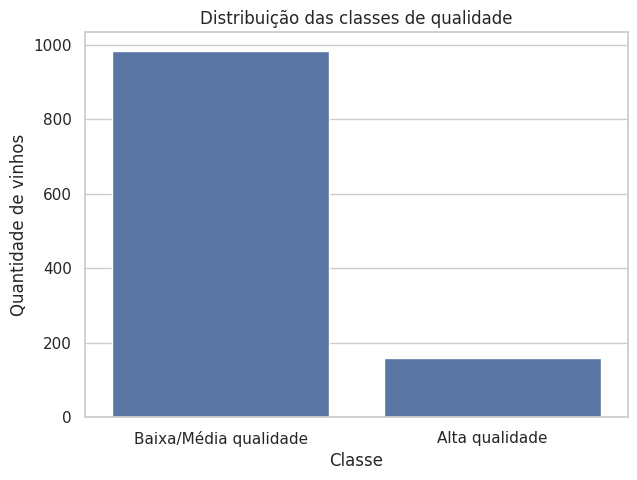

In [14]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="high_quality")
plt.title("Distribuição das classes de qualidade")
plt.xlabel("Classe")
plt.ylabel("Quantidade de vinhos")
plt.xticks([0, 1], ["Baixa/Média qualidade", "Alta qualidade"])
plt.show()

In [15]:
classe_percentual = df["high_quality"].value_counts(normalize=True) * 100
classe_percentual

,proportion
high_quality,
0,86.089239
1,13.910761


### Interpretação do balanceamento das classes

A análise da variável `high_quality` permite verificar se a base está balanceada ou desbalanceada.

Caso exista uma quantidade muito maior de vinhos de baixa/média qualidade em relação aos vinhos de alta qualidade, o problema será considerado desbalanceado.

Esse ponto é importante porque, em bases desbalanceadas, a acurácia pode ser uma métrica enganosa. Por isso, também serão utilizadas métricas como precision, recall, F1-score e ROC-AUC.

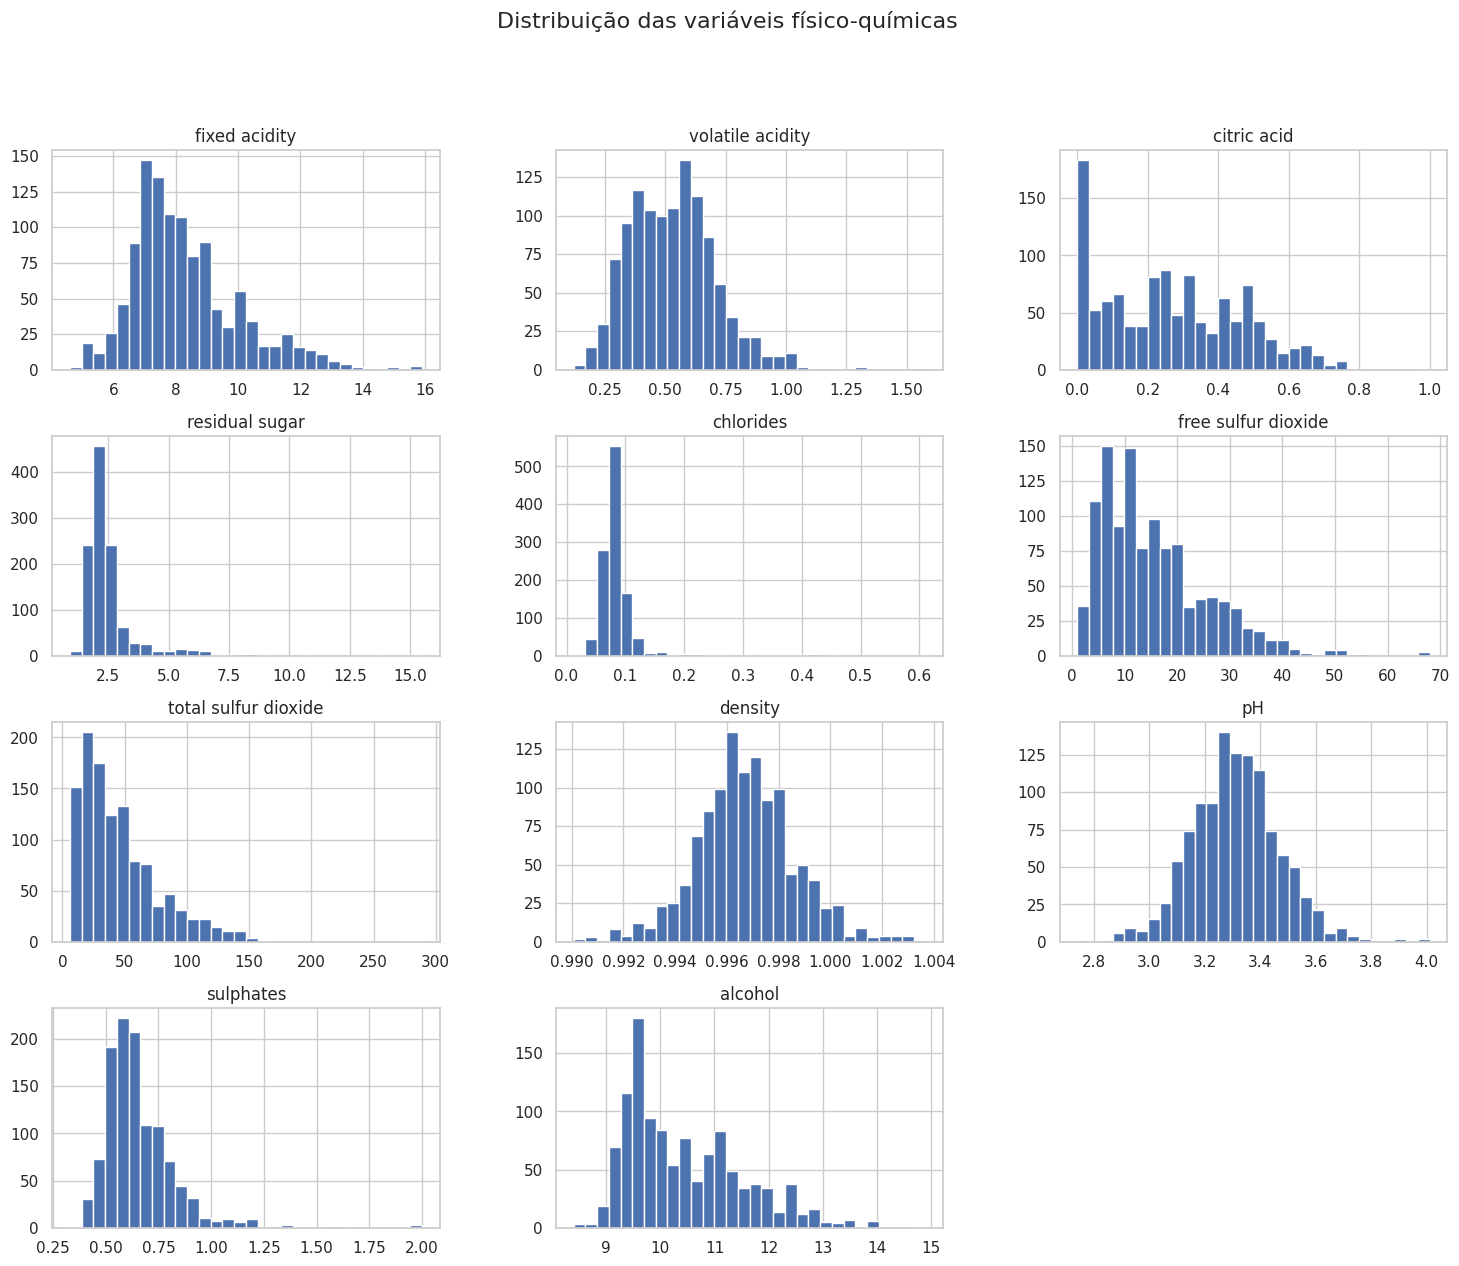

In [16]:
numeric_cols = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

df[numeric_cols].hist(figsize=(18, 14), bins=30)
plt.suptitle("Distribuição das variáveis físico-químicas", fontsize=16)
plt.show()

### Interpretação da distribuição das variáveis

A análise das distribuições permite observar o comportamento individual de cada variável físico-química.

Algumas variáveis podem apresentar distribuição mais simétrica, enquanto outras podem apresentar assimetria, concentração de valores baixos ou presença de valores extremos.

Essa etapa é importante para apoiar decisões de pré-processamento, como padronização das variáveis e análise de possíveis outliers.

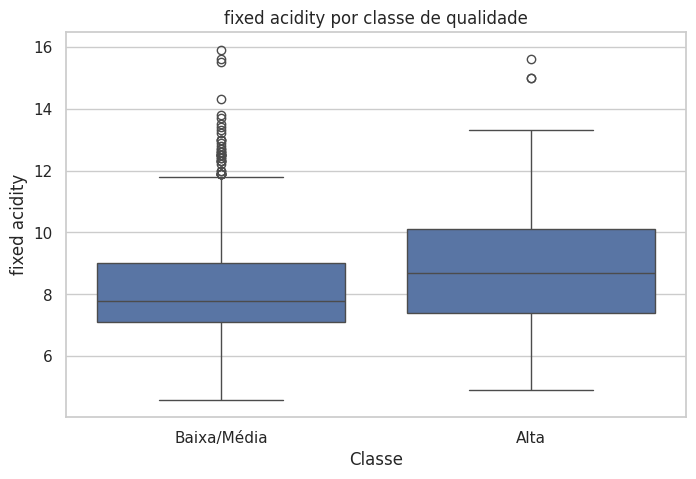

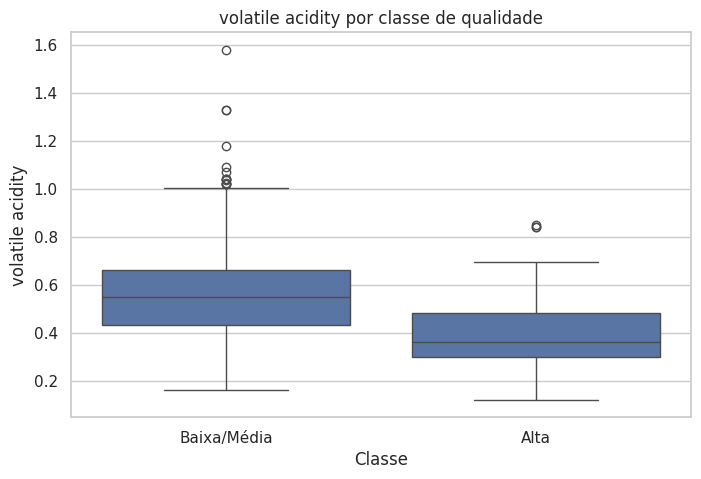

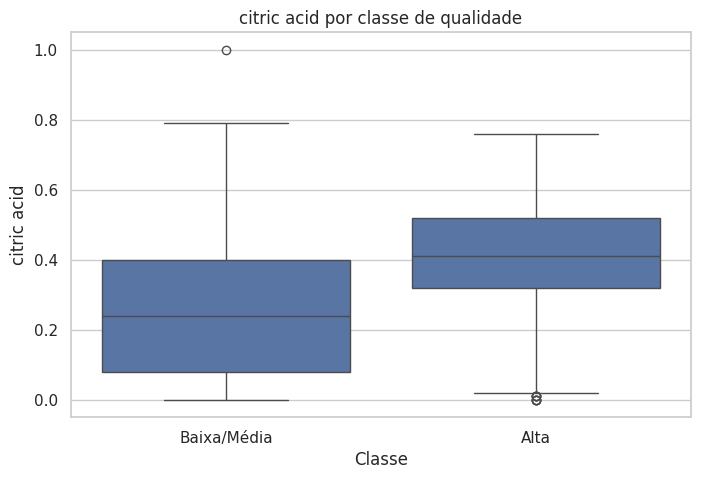

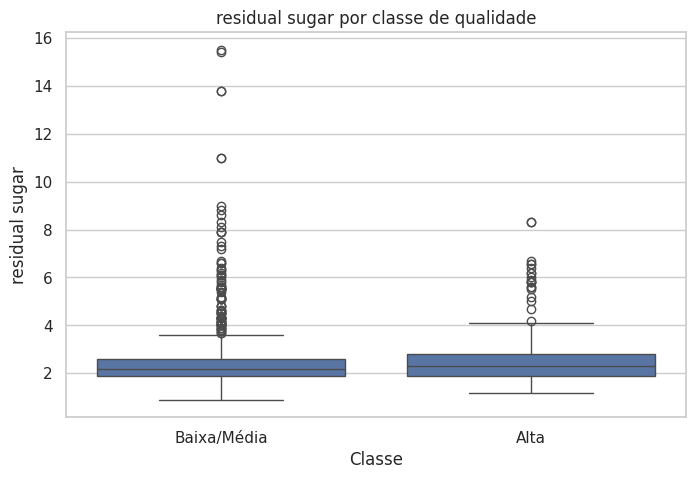

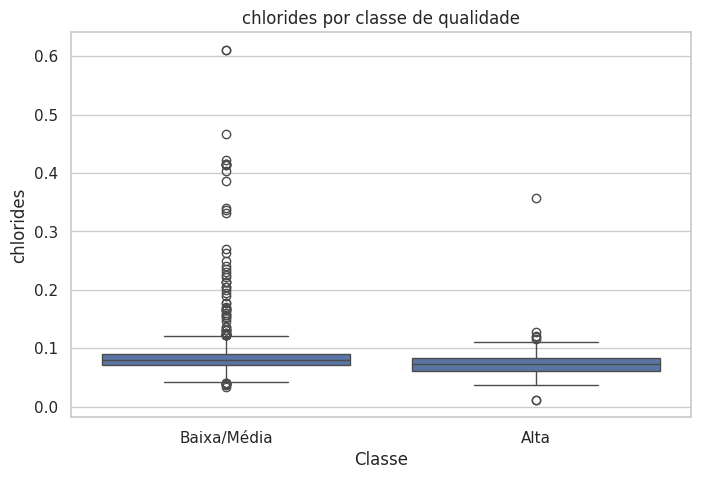

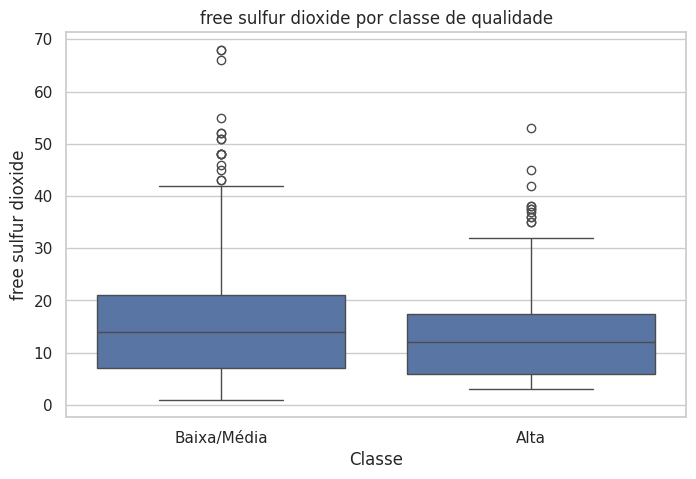

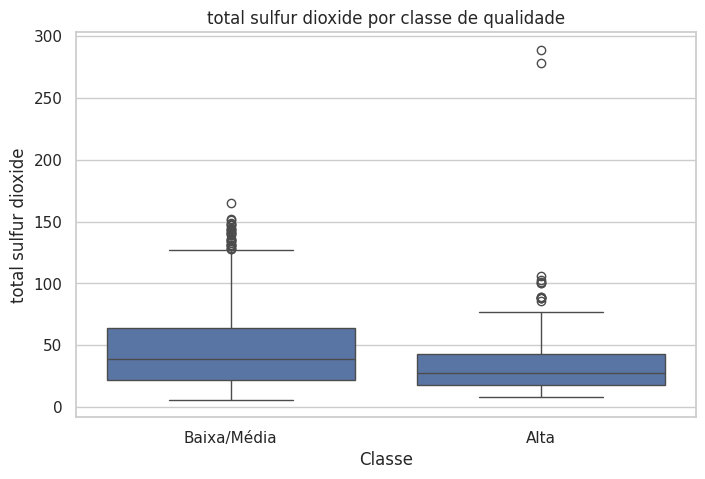

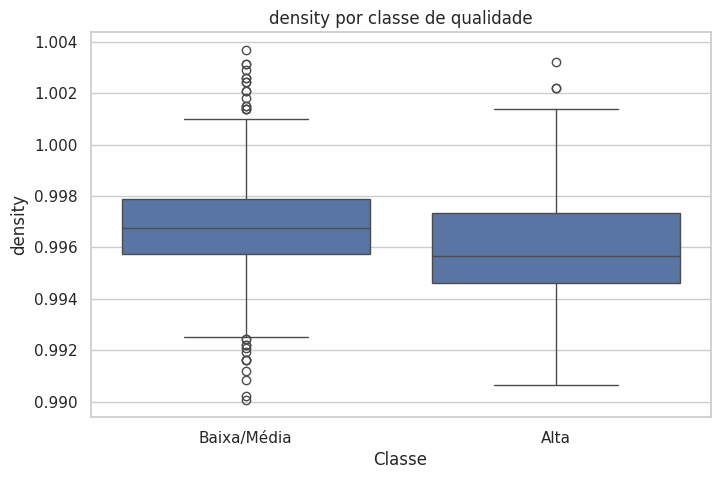

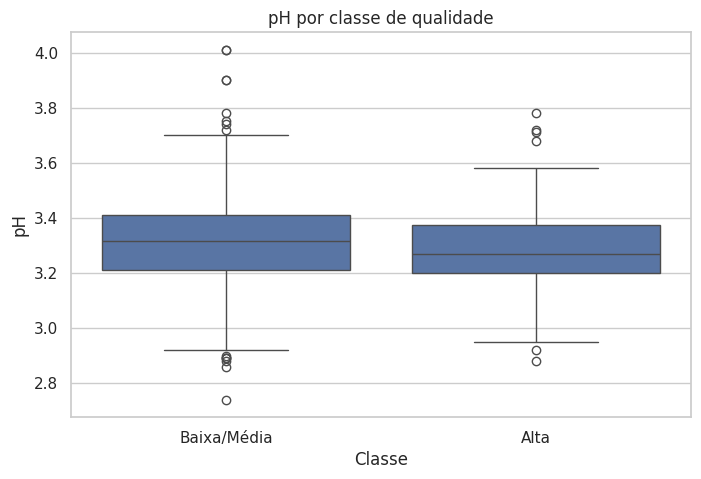

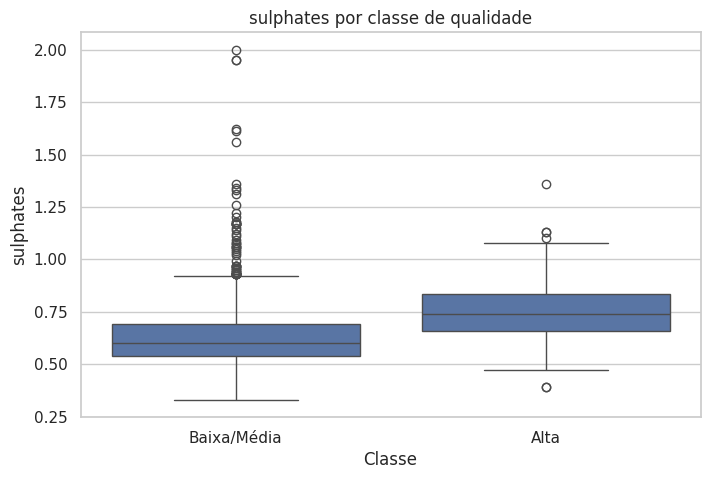

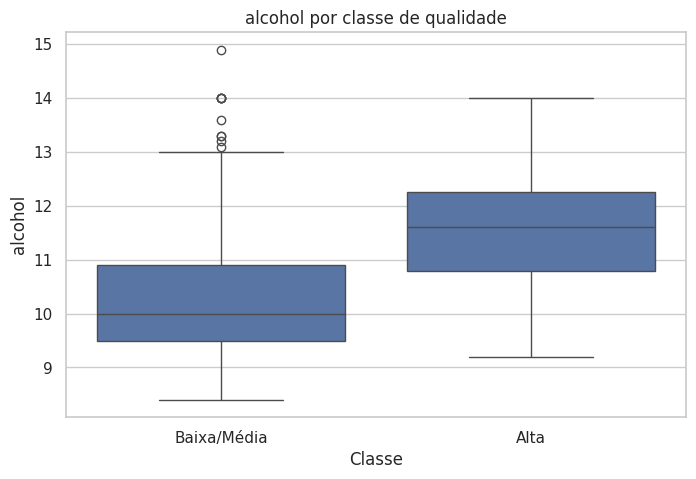

In [17]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="high_quality", y=col)
    plt.title(f"{col} por classe de qualidade")
    plt.xlabel("Classe")
    plt.ylabel(col)
    plt.xticks([0, 1], ["Baixa/Média", "Alta"])
    plt.show()

### Interpretação da comparação entre classes

Os boxplots permitem comparar o comportamento das variáveis físico-químicas entre vinhos de baixa/média qualidade e vinhos de alta qualidade.

Essa análise ajuda a identificar variáveis que parecem diferenciar melhor as classes.

Por exemplo, se vinhos de alta qualidade apresentarem valores maiores de álcool ou menores de acidez volátil, essas variáveis podem ser relevantes para o modelo.

## 7. Análise de correlação

Nesta seção, será analisada a correlação entre as variáveis numéricas.

A correlação mede o grau de associação linear entre duas variáveis.

Serão avaliadas:

- correlações entre as variáveis físico-químicas;
- correlação das variáveis com a nota `quality`;
- correlação das variáveis com a variável binária `high_quality`.

Essa análise ajuda a identificar quais características parecem estar mais associadas à qualidade do vinho.

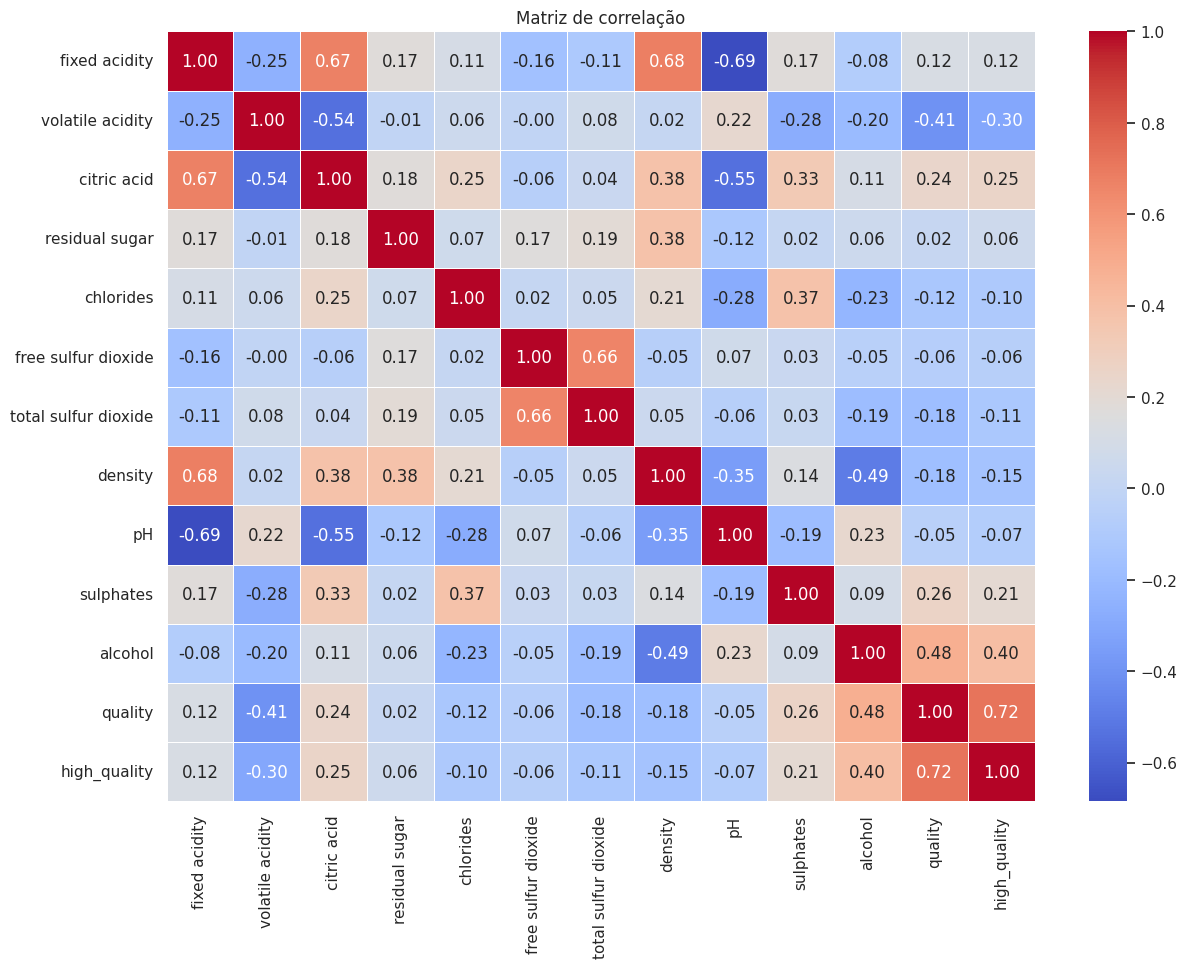

In [18]:
# Removendo a coluna Id da análise de correlação, caso exista
df_corr = df.drop(columns=["Id"], errors="ignore")

corr_matrix = df_corr.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de correlação")
plt.show()

In [19]:
# Correlação das variáveis com a variável alvo binária
corr_target = df_corr.corr()["high_quality"].sort_values(ascending=False)

corr_target

,high_quality
high_quality,1.000000
quality,0.720433
alcohol,0.403676
citric acid,0.251146
sulphates,0.208020
fixed acidity,0.123212
residual sugar,0.064145
free sulfur dioxide,-0.055977
pH,-0.073318
chlorides,-0.103985


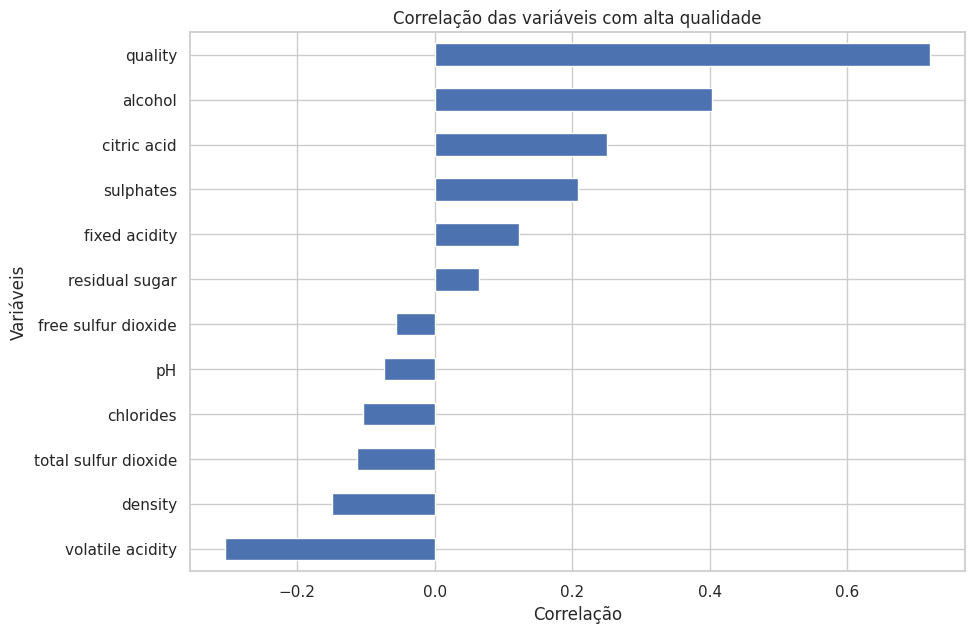

In [20]:
# Correlação em gráfico de barras
corr_target.drop("high_quality").sort_values().plot(kind="barh", figsize=(10, 7))
plt.title("Correlação das variáveis com alta qualidade")
plt.xlabel("Correlação")
plt.ylabel("Variáveis")
plt.show()

### Interpretação da análise de correlação

A matriz de correlação permite identificar relações positivas e negativas entre as variáveis.

Uma correlação positiva indica que, quando uma variável aumenta, a outra tende a aumentar também. Já uma correlação negativa indica que, quando uma variável aumenta, a outra tende a diminuir.

Nesta análise, o foco principal está nas variáveis mais associadas à classe de alta qualidade.

Variáveis com correlação positiva com `high_quality` podem estar associadas a maior probabilidade de um vinho ser classificado como alta qualidade.

Variáveis com correlação negativa podem estar associadas a menor probabilidade de alta qualidade.

É importante destacar que correlação não significa causalidade. Ou seja, uma variável estar associada à qualidade não significa, necessariamente, que ela seja a causa direta da qualidade do vinho.

## 8. Análise de outliers

Nesta seção, serão investigados possíveis outliers nas variáveis físico-químicas.

Outliers são valores muito distantes do comportamento geral dos dados.

A análise será feita por meio de boxplots e também pelo método do intervalo interquartil, conhecido como IQR.

O objetivo não é remover automaticamente os outliers, mas entender sua presença e avaliar se podem impactar os modelos.

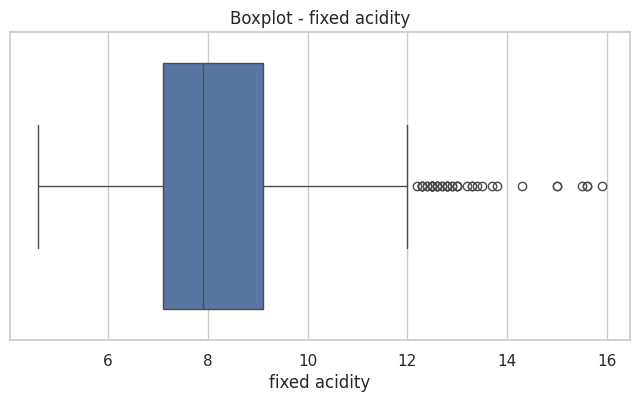

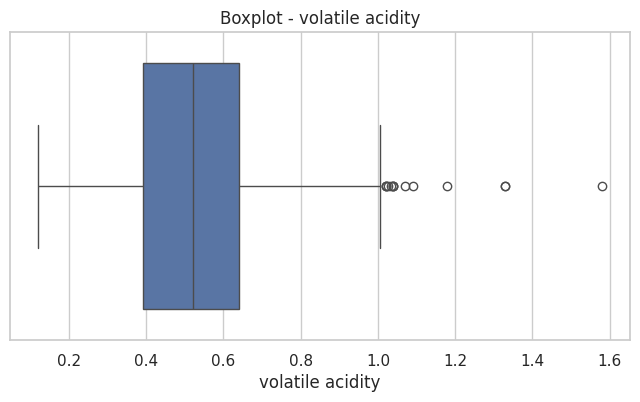

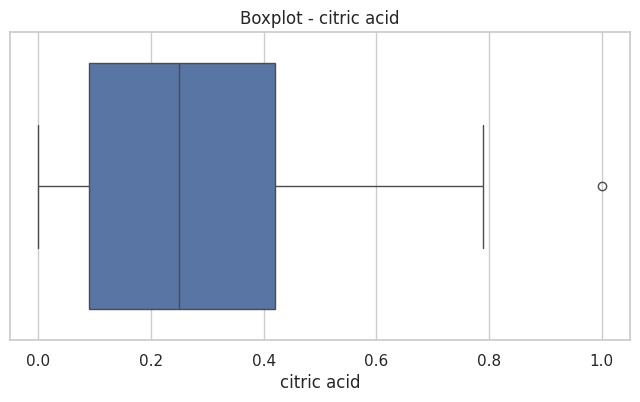

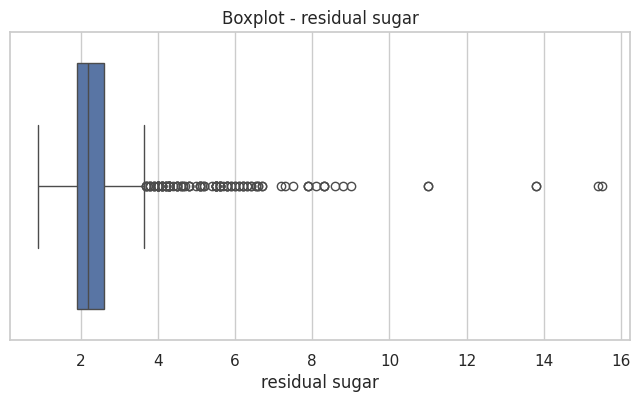

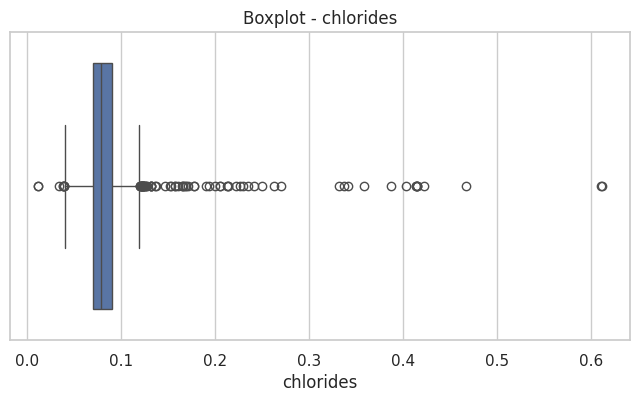

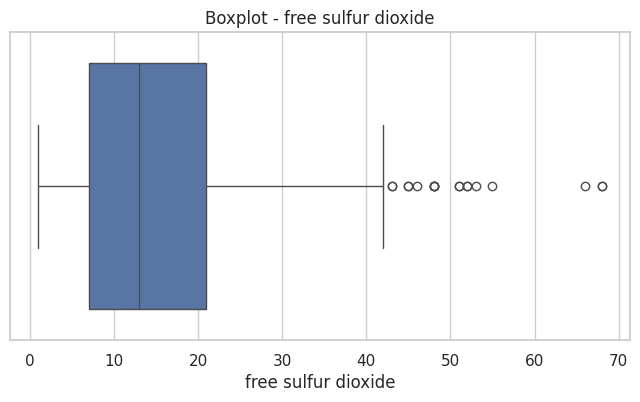

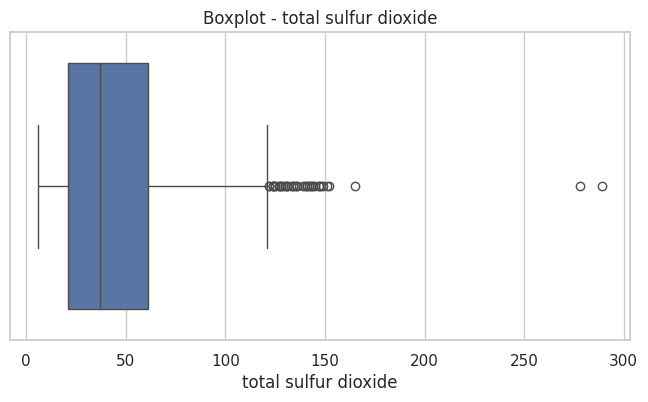

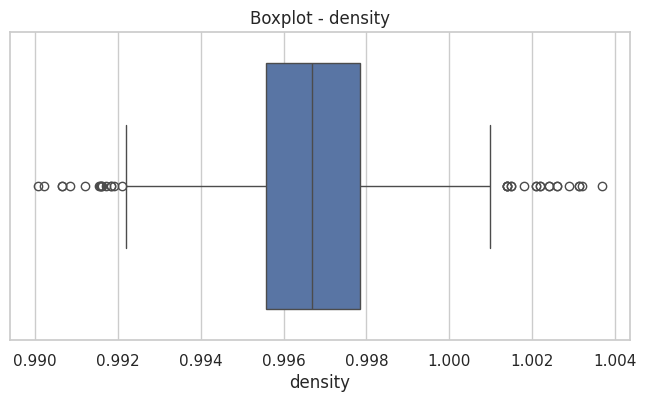

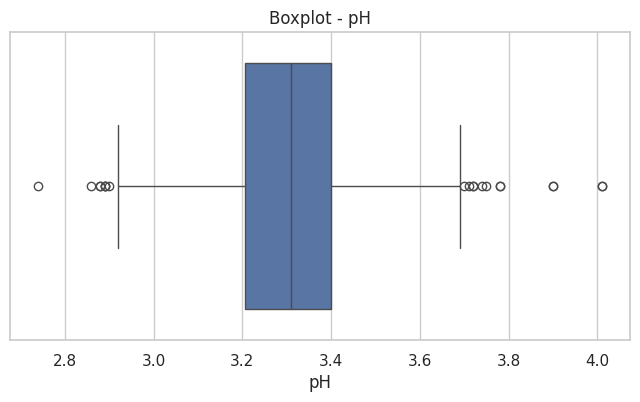

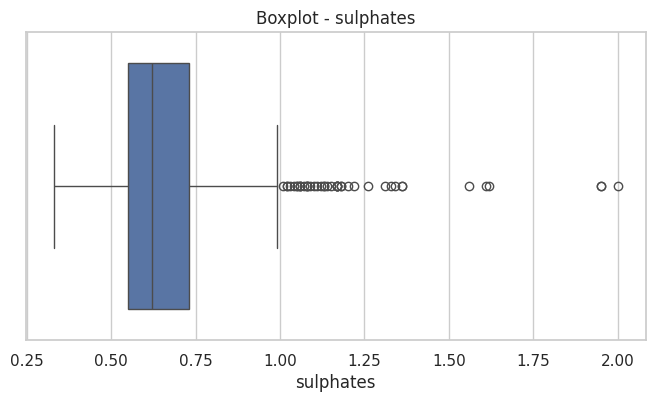

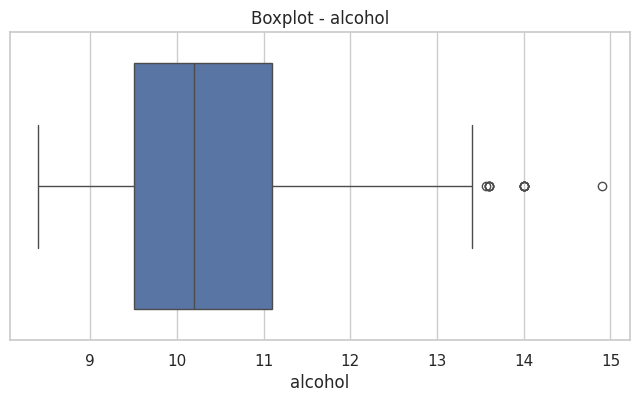

In [21]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

In [22]:
# Cálculo de outliers pelo método IQR
outliers_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    outliers_summary.append({
        "variavel": col,
        "limite_inferior": lower_limit,
        "limite_superior": upper_limit,
        "qtd_outliers": len(outliers),
        "percentual_outliers": len(outliers) / len(df) * 100
    })

outliers_df = pd.DataFrame(outliers_summary)
outliers_df.sort_values(by="qtd_outliers", ascending=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,percentual_outliers
3,residual sugar,0.850000,3.650000,110,9.623797
4,chlorides,0.040000,0.120000,77,6.736658
0,fixed acidity,4.100000,12.100000,44,3.849519
9,sulphates,0.280000,1.000000,43,3.762030
6,total sulfur dioxide,-39.000000,121.000000,40,3.499563
7,density,0.992157,1.001257,36,3.149606
8,pH,2.912500,3.692500,20,1.749781
5,free sulfur dioxide,-14.000000,42.000000,18,1.574803
1,volatile acidity,0.021250,1.011250,14,1.224847
10,alcohol,7.100000,13.500000,12,1.049869


### Interpretação dos outliers

Foram identificados possíveis outliers em algumas variáveis físico-químicas.

Como os dados representam medições reais de características dos vinhos, os valores extremos não serão removidos automaticamente.

A decisão adotada neste projeto será manter os outliers na base, pois eles podem representar variações legítimas do processo produtivo.

Além disso, será utilizado um modelo baseado em árvores, como Random Forest, que tende a ser menos sensível a outliers do que modelos puramente lineares.

## 9. Separação entre variáveis explicativas e variável alvo

Nesta seção, será feita a separação entre as variáveis utilizadas para prever a qualidade do vinho e a variável que será prevista.

As variáveis explicativas serão as características físico-químicas do vinho.

A variável alvo será `high_quality`.

As colunas `quality` e `Id` não serão utilizadas como variáveis explicativas:

- `quality` será removida porque deu origem à variável alvo;
- `Id` será removida porque é apenas um identificador da amostra.

In [23]:
X = df.drop(columns=["quality", "high_quality", "Id"], errors="ignore")
y = df["high_quality"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (1143, 11)
Formato de y: (1143,)


In [24]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [25]:
y.head()

,high_quality
0,0
1,0
2,0
3,0
4,0


## 10. Divisão entre treino e teste

Nesta etapa, a base será dividida em dados de treino e dados de teste.

Os dados de treino serão utilizados para treinar os modelos.

Os dados de teste serão utilizados para avaliar o desempenho dos modelos em dados que eles ainda não viram.

Como a base pode estar desbalanceada, será utilizado o parâmetro `stratify=y`, garantindo que a proporção entre as classes seja mantida nos conjuntos de treino e teste.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (914, 11)
X_test: (229, 11)
y_train: (914,)
y_test: (229,)


In [27]:
print("Distribuição no treino:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True) * 100)

Distribuição no treino:
high_quality
0    86.105033
1    13.894967
Name: proportion, dtype: float64

Distribuição no teste:
high_quality
0    86.026201
1    13.973799
Name: proportion, dtype: float64


## 11. Pré-processamento dos dados

Nesta seção, será aplicado o pré-processamento necessário para os modelos.

Como todas as variáveis explicativas são numéricas, o principal tratamento será a padronização das variáveis.

A padronização será aplicada especialmente para a Regressão Logística, que é sensível à escala das variáveis.

Para evitar vazamento de dados, a padronização será feita dentro de um `Pipeline`, garantindo que o `StandardScaler` seja ajustado apenas nos dados de treino.

## 12. Treinamento dos modelos

Nesta seção, serão treinados três modelos de classificação:

1. Regressão Logística;
2. Random Forest;
3. Gradient Boosting.

A Regressão Logística será utilizada como modelo base, por ser simples e interpretável.

A Random Forest será utilizada por conseguir capturar relações não lineares entre as variáveis.

O Gradient Boosting será incluído como modelo adicional para comparação, pois é uma técnica robusta de aprendizado sequencial.

O objetivo é comparar os modelos e selecionar aquele com melhor desempenho para o problema.

In [28]:
# Modelo 1: Regressão Logística com padronização
logistic_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

# Modelo 2: Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

# Modelo 3: Gradient Boosting
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [29]:
# Treinamento dos modelos
logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)
gradient_boosting_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [30]:
# Predições
y_pred_logistic = logistic_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)
y_pred_gb = gradient_boosting_model.predict(X_test)

# Probabilidades para cálculo do ROC-AUC
y_proba_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]
y_proba_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

## 13. Avaliação dos modelos

Nesta seção, os modelos serão avaliados com métricas adequadas para classificação binária.

As métricas utilizadas serão:

- Acurácia: percentual geral de acertos;
- Precision: entre os vinhos previstos como alta qualidade, quantos realmente eram de alta qualidade;
- Recall: entre os vinhos que realmente eram de alta qualidade, quantos o modelo conseguiu identificar;
- F1-score: média harmônica entre precision e recall;
- ROC-AUC: capacidade do modelo de separar as duas classes.

Como a base possui desbalanceamento entre as classes, a análise não deve depender apenas da acurácia.

In [31]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    return {
        "Modelo": model_name,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

In [32]:
results = []

results.append(evaluate_model(
    "Regressão Logística",
    y_test,
    y_pred_logistic,
    y_proba_logistic
))

results.append(evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_proba_rf
))

results.append(evaluate_model(
    "Gradient Boosting",
    y_test,
    y_pred_gb,
    y_proba_gb
))

results_df = pd.DataFrame(results)
results_df

,Modelo,Acurácia,Precision,Recall,F1-score,ROC-AUC
0,Regressão Logística,0.799127,0.379310,0.68750,0.488889,0.850412
1,Random Forest,0.917031,0.740741,0.62500,0.677966,0.907519
2,Gradient Boosting,0.899563,0.680000,0.53125,0.596491,0.871827


In [33]:
# Ordenando os modelos pelo F1-score
results_df.sort_values(by="F1-score", ascending=False)

,Modelo,Acurácia,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.917031,0.740741,0.62500,0.677966,0.907519
2,Gradient Boosting,0.899563,0.680000,0.53125,0.596491,0.871827
0,Regressão Logística,0.799127,0.379310,0.68750,0.488889,0.850412


## 14. Relatório de classificação

Nesta seção, será apresentado o relatório de classificação de cada modelo.

Esse relatório mostra as métricas de precision, recall e F1-score separadas por classe.

Essa visão é importante porque permite avaliar não apenas o desempenho geral, mas também como o modelo se comporta na classe de alta qualidade, que é a classe mais importante para o problema.

In [34]:
print("Regressão Logística")
print(classification_report(y_test, y_pred_logistic, target_names=["Baixa/Média", "Alta"]))

Regressão Logística
              precision    recall  f1-score   support

 Baixa/Média       0.94      0.82      0.88       197
        Alta       0.38      0.69      0.49        32

    accuracy                           0.80       229
   macro avg       0.66      0.75      0.68       229
weighted avg       0.86      0.80      0.82       229



In [35]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=["Baixa/Média", "Alta"]))

Random Forest
              precision    recall  f1-score   support

 Baixa/Média       0.94      0.96      0.95       197
        Alta       0.74      0.62      0.68        32

    accuracy                           0.92       229
   macro avg       0.84      0.79      0.82       229
weighted avg       0.91      0.92      0.91       229



In [36]:
print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb, target_names=["Baixa/Média", "Alta"]))

Gradient Boosting
              precision    recall  f1-score   support

 Baixa/Média       0.93      0.96      0.94       197
        Alta       0.68      0.53      0.60        32

    accuracy                           0.90       229
   macro avg       0.80      0.75      0.77       229
weighted avg       0.89      0.90      0.89       229



## 15. Matriz de confusão

Nesta seção, será analisada a matriz de confusão dos modelos.

A matriz de confusão mostra:

- Verdadeiros negativos: vinhos de baixa/média qualidade classificados corretamente;
- Verdadeiros positivos: vinhos de alta qualidade classificados corretamente;
- Falsos positivos: vinhos de baixa/média qualidade classificados como alta qualidade;
- Falsos negativos: vinhos de alta qualidade classificados como baixa/média qualidade.

Para o contexto de negócio, os falsos negativos são especialmente importantes, pois representam vinhos de alta qualidade que o modelo não conseguiu reconhecer.

In [37]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Baixa/Média", "Alta"],
        yticklabels=["Baixa/Média", "Alta"]
    )
    plt.title(f"Matriz de Confusão - {model_name}")
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.show()

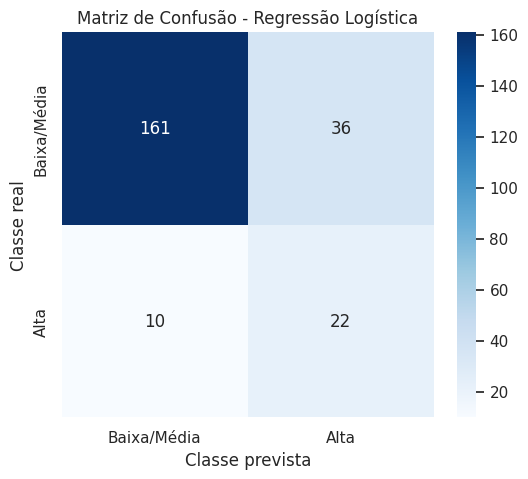

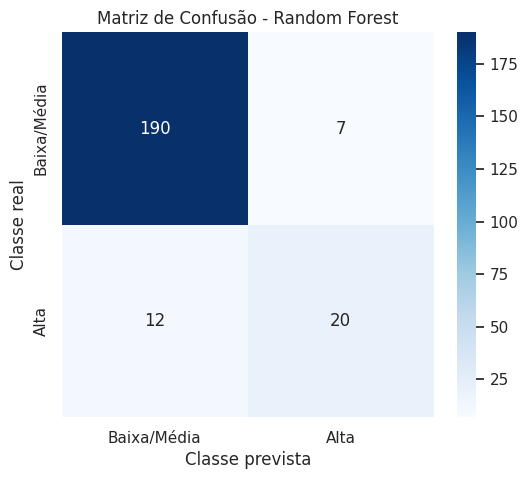

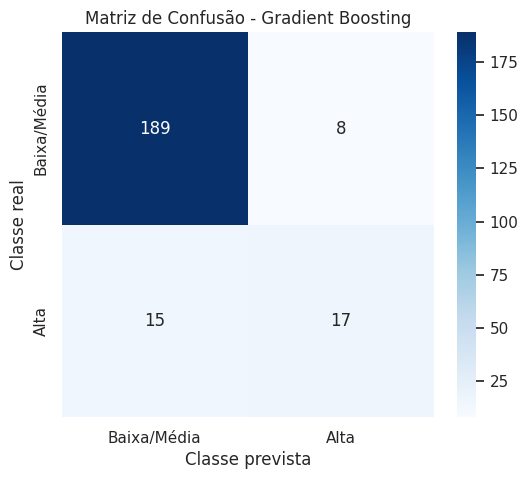

In [38]:
plot_confusion_matrix(y_test, y_pred_logistic, "Regressão Logística")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(y_test, y_pred_gb, "Gradient Boosting")

## 16. Curva ROC

Nesta seção, será analisada a Curva ROC dos modelos.

A Curva ROC mostra a capacidade do modelo de separar vinhos de alta qualidade dos vinhos de baixa/média qualidade.

Quanto maior o valor de ROC-AUC, melhor tende a ser a capacidade de separação do modelo.

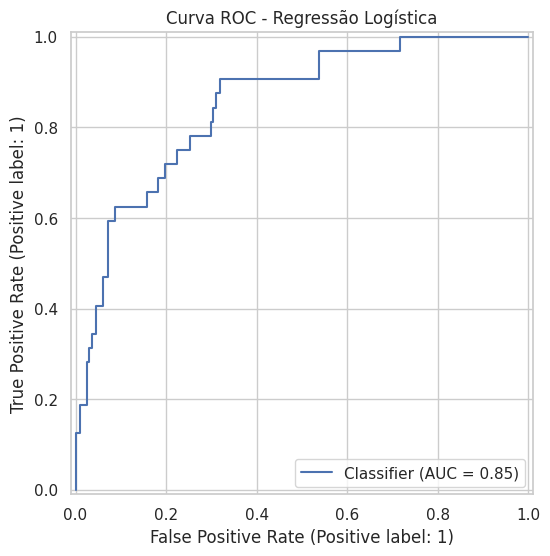

In [39]:
RocCurveDisplay.from_predictions(y_test, y_proba_logistic)
plt.title("Curva ROC - Regressão Logística")
plt.show()

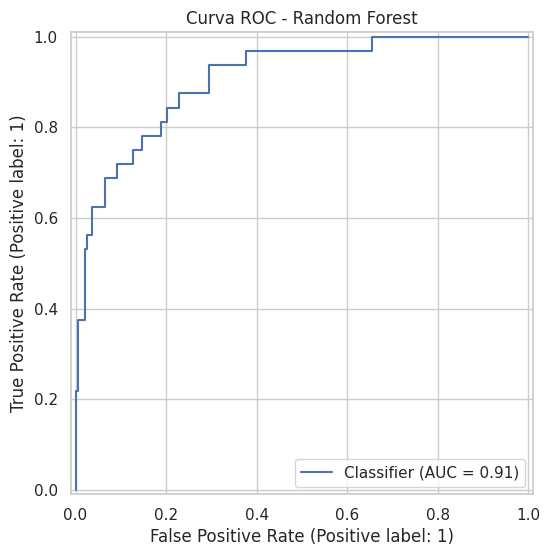

In [40]:
RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Curva ROC - Random Forest")
plt.show()

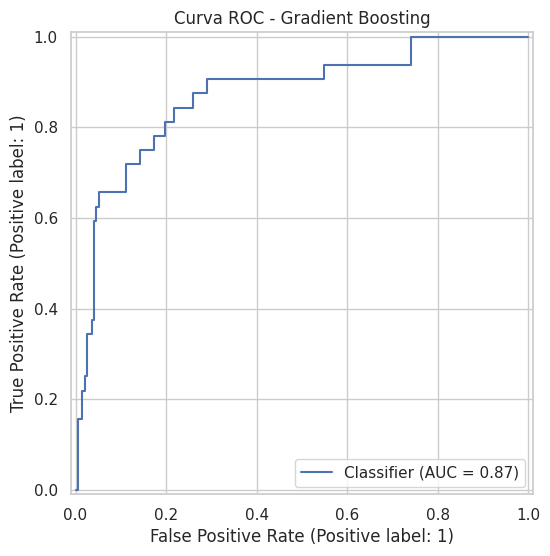

In [41]:
RocCurveDisplay.from_predictions(y_test, y_proba_gb)
plt.title("Curva ROC - Gradient Boosting")
plt.show()

## 17. Comparação final dos modelos

Nesta seção, os resultados dos modelos serão comparados em uma única tabela.

A escolha do melhor modelo será baseada principalmente no F1-score, recall da classe de alta qualidade e ROC-AUC.

Como o objetivo é identificar vinhos de alta qualidade, é importante que o modelo tenha boa capacidade de encontrar corretamente essa classe.

In [42]:
results_df_sorted = results_df.sort_values(by="F1-score", ascending=False)
results_df_sorted

,Modelo,Acurácia,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.917031,0.740741,0.62500,0.677966,0.907519
2,Gradient Boosting,0.899563,0.680000,0.53125,0.596491,0.871827
0,Regressão Logística,0.799127,0.379310,0.68750,0.488889,0.850412


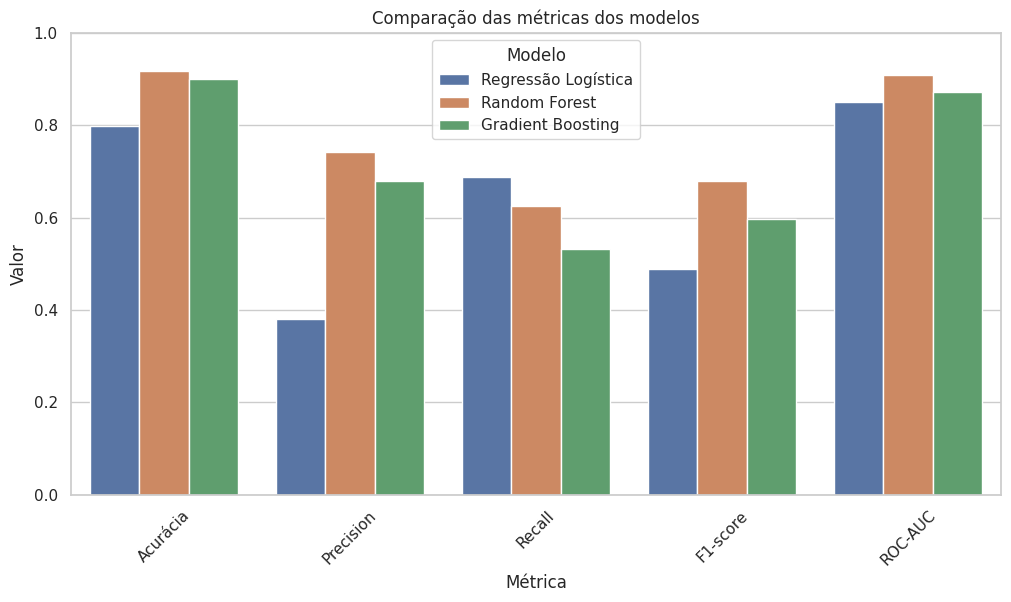

In [43]:
# Gráfico comparativo das métricas
results_melted = results_df.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x="Métrica", y="Valor", hue="Modelo")
plt.title("Comparação das métricas dos modelos")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

### Interpretação da comparação dos modelos

A comparação dos modelos permite identificar qual algoritmo apresentou melhor desempenho geral.

Como o problema possui desbalanceamento de classes, a análise não deve considerar apenas a acurácia.

O F1-score é uma métrica importante porque equilibra precision e recall.

O recall também merece atenção, pois indica a capacidade do modelo de identificar corretamente os vinhos de alta qualidade.

O modelo escolhido deve ser aquele que apresenta melhor equilíbrio entre desempenho preditivo e utilidade para o problema de negócio.

## 18. Interpretação das variáveis mais importantes

Nesta seção, será analisada a importância das variáveis para o modelo Random Forest.

A análise de importância permite identificar quais características físico-químicas mais contribuíram para a classificação dos vinhos.

Essa etapa ajuda a transformar o resultado do modelo em insights de negócio, indicando quais fatores podem estar mais associados à qualidade final do vinho.

In [44]:
feature_importance_rf = pd.DataFrame({
    "Variável": X.columns,
    "Importância": random_forest_model.feature_importances_
}).sort_values(by="Importância", ascending=False)

feature_importance_rf

,Variável,Importância
10,alcohol,0.223373
2,citric acid,0.147406
9,sulphates,0.143299
1,volatile acidity,0.113028
7,density,0.069171
0,fixed acidity,0.063208
6,total sulfur dioxide,0.061589
4,chlorides,0.052870
8,pH,0.047318
3,residual sugar,0.042332


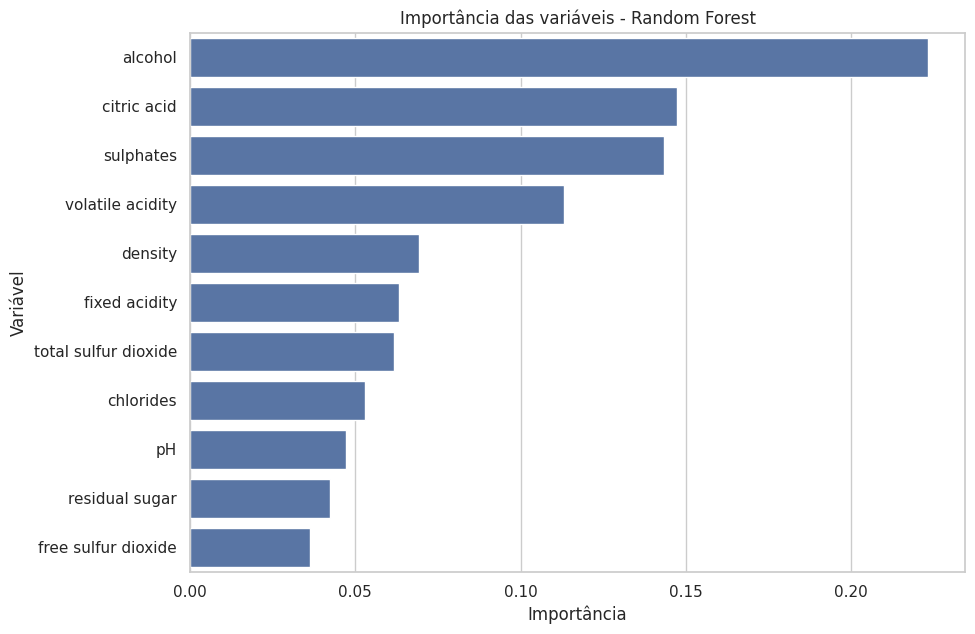

In [45]:
plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance_rf, x="Importância", y="Variável")
plt.title("Importância das variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

### Interpretação da importância das variáveis

A análise de importância das variáveis mostra quais características físico-químicas mais contribuíram para a classificação dos vinhos.

Variáveis como teor alcoólico, acidez volátil, sulfatos, ácido cítrico e densidade podem aparecer entre os fatores mais relevantes.

Do ponto de vista de negócio, esses resultados podem apoiar produtores e enólogos na identificação de características associadas à maior qualidade do vinho.

É importante destacar que a importância do modelo indica associação preditiva, não necessariamente causalidade direta.

## 19. Validação cruzada

Nesta seção, será aplicada validação cruzada para avaliar a estabilidade dos modelos.

A validação cruzada divide os dados em diferentes partes e treina o modelo várias vezes, alternando os dados de treino e validação.

Essa técnica ajuda a verificar se o desempenho do modelo é consistente ou se depende muito de uma única divisão entre treino e teste.

In [46]:
models = {
    "Regressão Logística": logistic_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="f1"
    )

    cv_results.append({
        "Modelo": name,
        "F1 médio": scores.mean(),
        "Desvio padrão": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values(by="F1 médio", ascending=False)

,Modelo,F1 médio,Desvio padrão
0,Regressão Logística,0.508663,0.072741
1,Random Forest,0.440276,0.132041
2,Gradient Boosting,0.437156,0.112107


### Interpretação da validação cruzada

A validação cruzada permite avaliar se o desempenho dos modelos é estável em diferentes divisões da base.

Um F1 médio mais alto indica melhor desempenho geral.

Um desvio padrão menor indica maior estabilidade do modelo.

Essa análise ajuda a escolher um modelo que não tenha performado bem apenas por acaso em uma única divisão de treino e teste.

## 20. Seleção do modelo final

Com base nas métricas avaliadas, será escolhido o modelo final do projeto.

A seleção considera:

- F1-score;
- Recall da classe de alta qualidade;
- ROC-AUC;
- Matriz de confusão;
- Estabilidade na validação cruzada;
- Capacidade de interpretação dos resultados.

O modelo escolhido será utilizado como principal recomendação para classificação da qualidade dos vinhos.

In [47]:
best_model_name = results_df_sorted.iloc[0]["Modelo"]
best_model_name

'Random Forest'

### Justificativa da escolha do modelo

O modelo final deve ser escolhido considerando não apenas a maior acurácia, mas principalmente sua capacidade de identificar corretamente os vinhos de alta qualidade.

Como a classe de alta qualidade é menor na base, métricas como recall e F1-score são mais adequadas para avaliar o desempenho.

O modelo selecionado será aquele que apresentar o melhor equilíbrio entre identificação da classe positiva, estabilidade e capacidade de gerar insights úteis para o negócio.

## 21. Conclusão executiva

O projeto demonstrou que é possível utilizar dados físico-químicos para apoiar a classificação da qualidade dos vinhos.

A análise exploratória indicou que a maioria dos vinhos está concentrada em notas intermediárias, enquanto os vinhos de alta qualidade representam uma parcela menor da base.

Foram treinados e comparados modelos de Machine Learning para classificar os vinhos em alta qualidade ou baixa/média qualidade.

As métricas utilizadas permitiram avaliar o desempenho dos modelos de forma mais adequada, considerando o desbalanceamento entre as classes.

As variáveis mais importantes identificadas pelo modelo indicam que características como teor alcoólico, acidez volátil, sulfatos, ácido cítrico e densidade podem estar associadas à qualidade final do vinho.

Do ponto de vista de negócio, o modelo pode ser utilizado como uma ferramenta de apoio à decisão, auxiliando produtores e enólogos na identificação de padrões físico-químicos relacionados à qualidade.

O modelo não substitui a avaliação de especialistas, mas pode complementar o processo de análise e contribuir para maior padronização e eficiência na produção.

## 22. Exportação dos resultados

Nesta seção, serão exportados os principais resultados do projeto.

Serão salvos:

- tabela comparativa de métricas dos modelos;
- tabela de importância das variáveis;
- gráficos gerados durante a análise.

Esses arquivos poderão ser utilizados posteriormente no README, na apresentação executiva e no repositório do GitHub.

In [48]:
import os

os.makedirs("results", exist_ok=True)

In [49]:
# Exportando métricas dos modelos
results_df.to_csv("results/metricas_modelos.csv", index=False)

# Exportando importância das variáveis
feature_importance_rf.to_csv("results/importancia_variaveis_random_forest.csv", index=False)

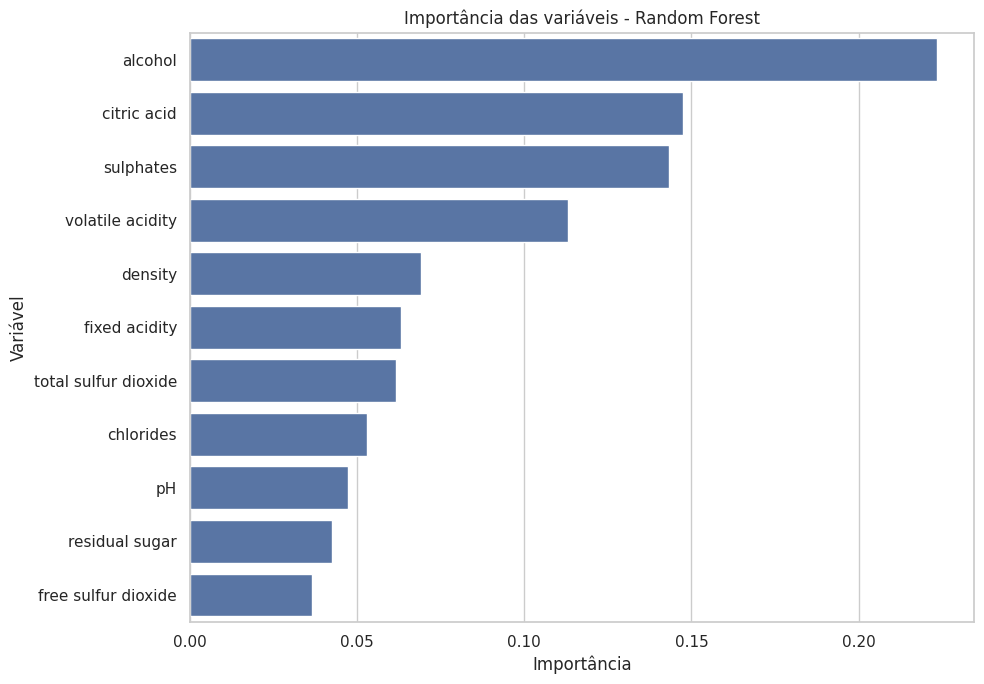

In [61]:
# Salvando gráfico de importância das variáveis
plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance_rf, x="Importância", y="Variável")
plt.title("Importância das variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.savefig("results/importancia_variaveis_random_forest.png", dpi=300)
plt.show()
plt.close()

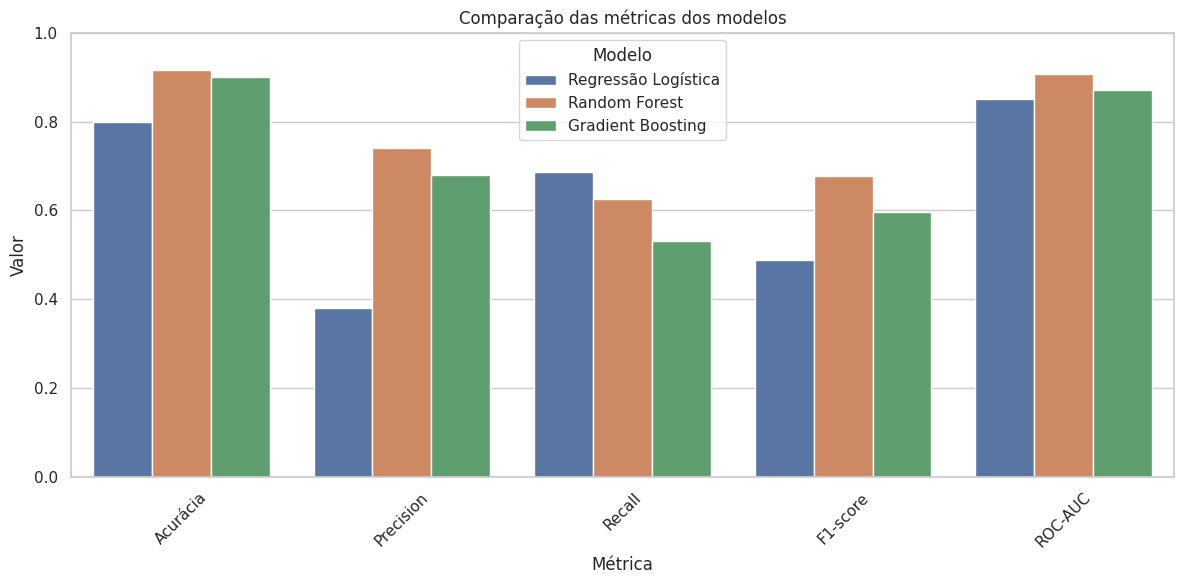

In [51]:
# Salvando gráfico comparativo de métricas
plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x="Métrica", y="Valor", hue="Modelo")
plt.title("Comparação das métricas dos modelos")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("results/comparacao_metricas_modelos.png", dpi=300)
plt.show()
plt.close()

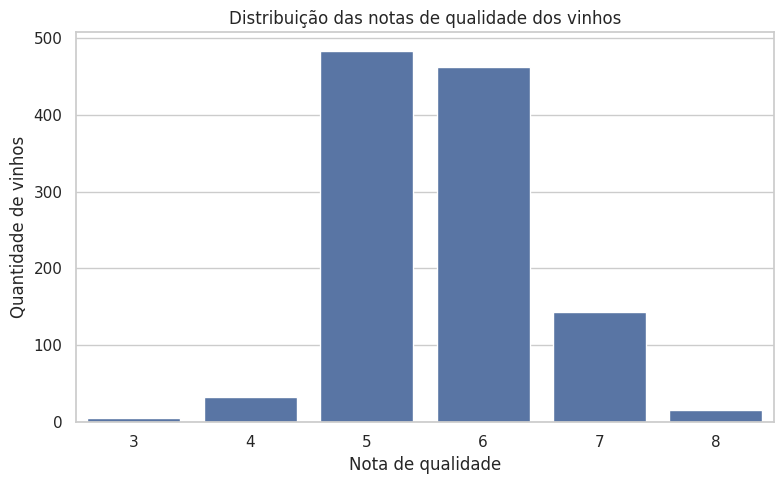

In [54]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="quality")
plt.title("Distribuição das notas de qualidade dos vinhos")
plt.xlabel("Nota de qualidade")
plt.ylabel("Quantidade de vinhos")
plt.tight_layout()
plt.savefig("results/distribuicao_quality.png", dpi=300)
plt.show()
plt.close()

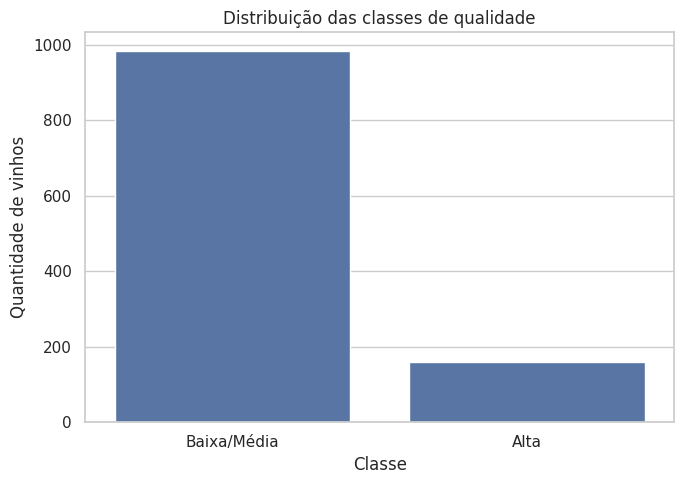

In [55]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="high_quality")
plt.title("Distribuição das classes de qualidade")
plt.xlabel("Classe")
plt.ylabel("Quantidade de vinhos")
plt.xticks([0, 1], ["Baixa/Média", "Alta"])
plt.tight_layout()
plt.savefig("results/distribuicao_high_quality.png", dpi=300)
plt.show()
plt.close()

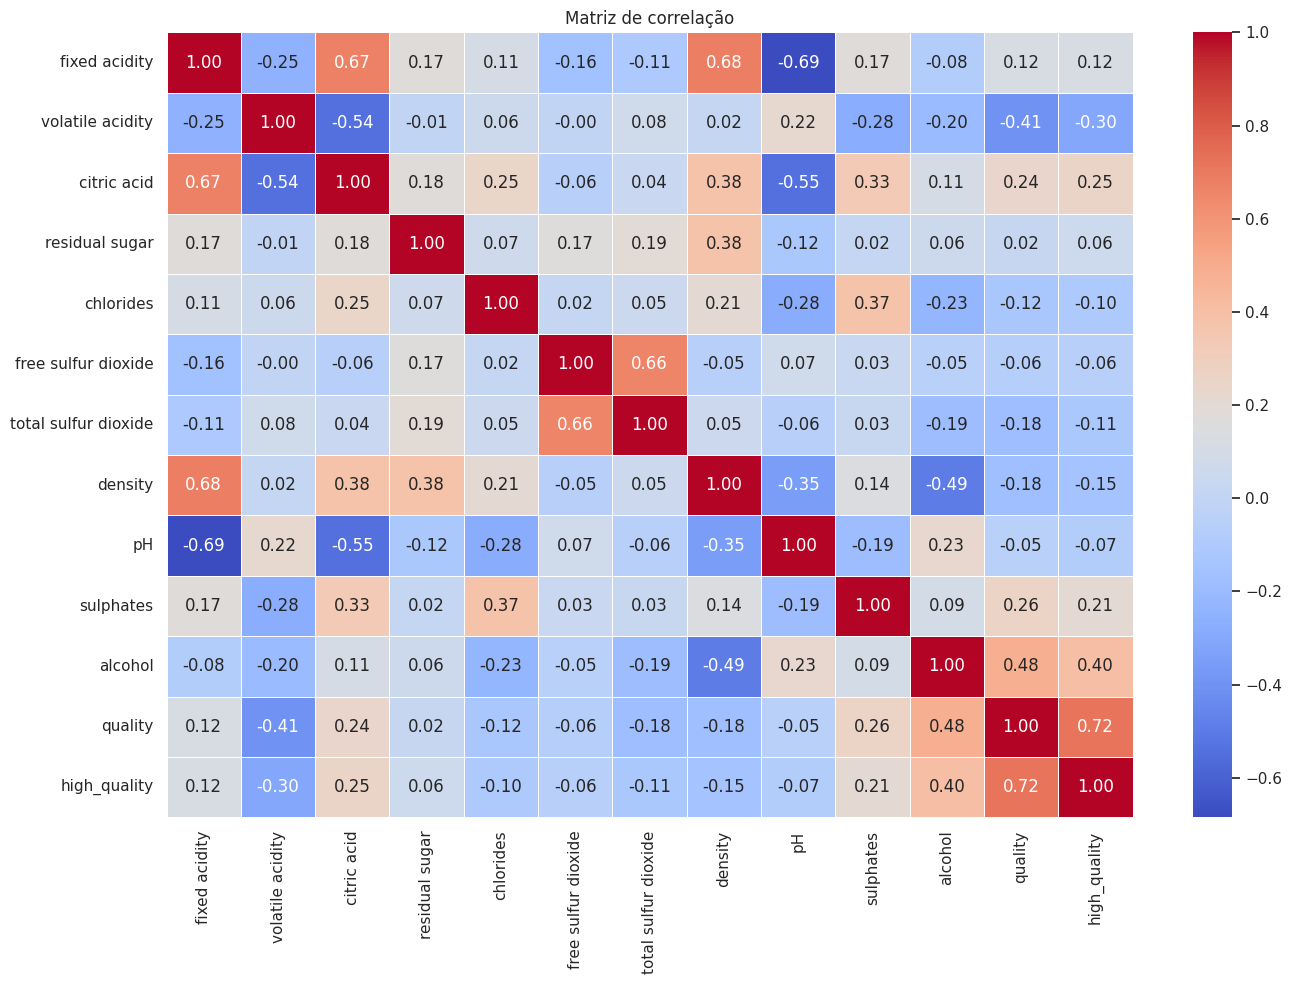

In [56]:
df_corr = df.drop(columns=["Id"], errors="ignore")
corr_matrix = df_corr.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.savefig("results/matriz_correlacao.png", dpi=300)
plt.show()
plt.close()

In [57]:
outliers_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    outliers_summary.append({
        "variavel": col,
        "limite_inferior": lower_limit,
        "limite_superior": upper_limit,
        "qtd_outliers": len(outliers),
        "percentual_outliers": len(outliers) / len(df) * 100
    })

outliers_df = pd.DataFrame(outliers_summary)
outliers_df.to_csv("results/resumo_outliers.csv", index=False)

outliers_df.sort_values(by="qtd_outliers", ascending=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,percentual_outliers
3,residual sugar,0.850000,3.650000,110,9.623797
4,chlorides,0.040000,0.120000,77,6.736658
0,fixed acidity,4.100000,12.100000,44,3.849519
9,sulphates,0.280000,1.000000,43,3.762030
6,total sulfur dioxide,-39.000000,121.000000,40,3.499563
7,density,0.992157,1.001257,36,3.149606
8,pH,2.912500,3.692500,20,1.749781
5,free sulfur dioxide,-14.000000,42.000000,18,1.574803
1,volatile acidity,0.021250,1.011250,14,1.224847
10,alcohol,7.100000,13.500000,12,1.049869


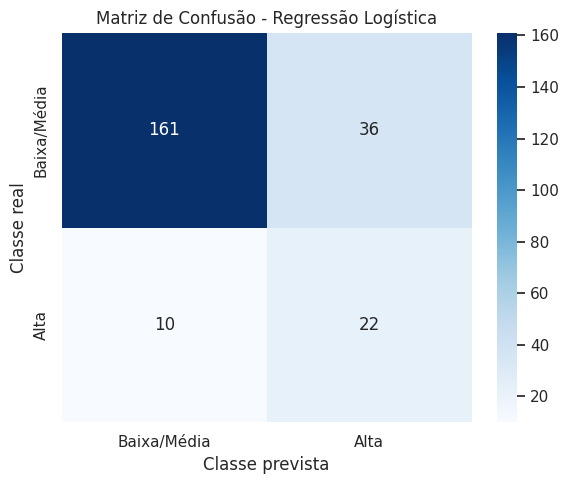

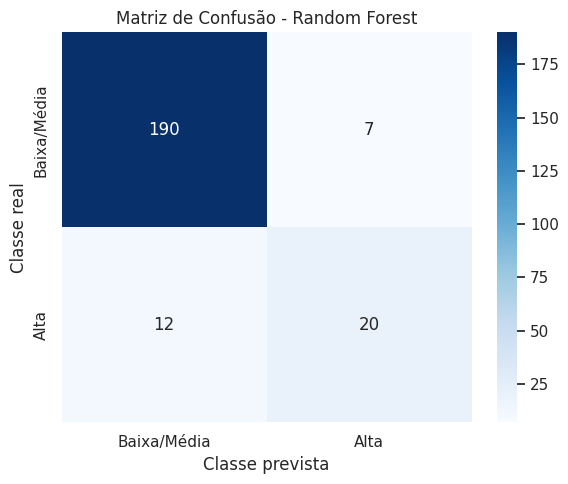

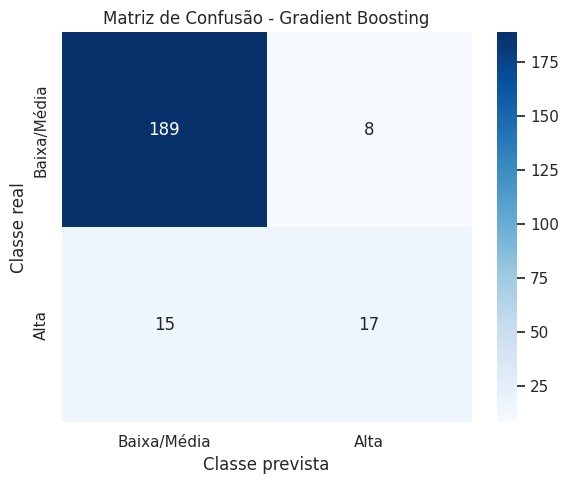

In [58]:
def save_confusion_matrix(y_true, y_pred, model_name, file_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Baixa/Média", "Alta"],
        yticklabels=["Baixa/Média", "Alta"]
    )

    plt.title(f"Matriz de Confusão - {model_name}")
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.tight_layout()
    plt.savefig(f"results/{file_name}", dpi=300)
    plt.show()
    plt.close()


save_confusion_matrix(y_test, y_pred_logistic, "Regressão Logística", "matriz_confusao_logistica.png")
save_confusion_matrix(y_test, y_pred_rf, "Random Forest", "matriz_confusao_random_forest.png")
save_confusion_matrix(y_test, y_pred_gb, "Gradient Boosting", "matriz_confusao_gradient_boosting.png")

In [59]:
from sklearn.metrics import classification_report

with open("results/classification_reports.txt", "w") as f:
    f.write("Regressão Logística\n")
    f.write(classification_report(y_test, y_pred_logistic, target_names=["Baixa/Média", "Alta"]))
    f.write("\n\nRandom Forest\n")
    f.write(classification_report(y_test, y_pred_rf, target_names=["Baixa/Média", "Alta"]))
    f.write("\n\nGradient Boosting\n")
    f.write(classification_report(y_test, y_pred_gb, target_names=["Baixa/Média", "Alta"]))

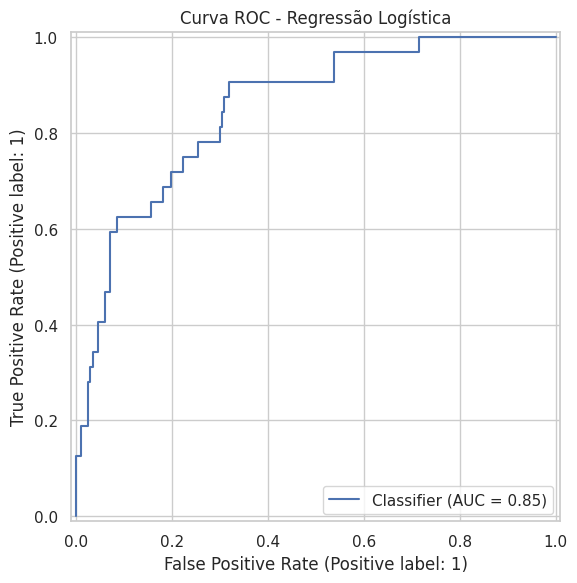

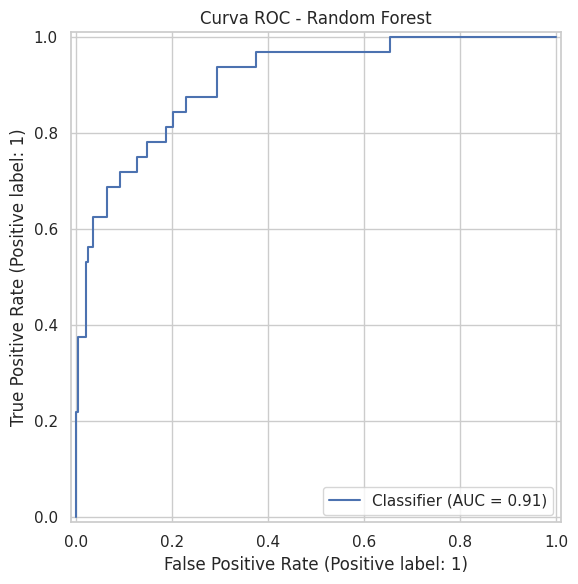

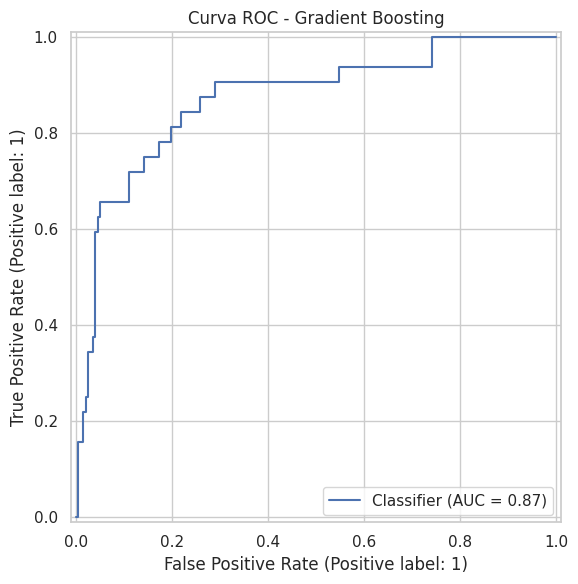

In [60]:
RocCurveDisplay.from_predictions(y_test, y_proba_logistic)
plt.title("Curva ROC - Regressão Logística")
plt.tight_layout()
plt.savefig("results/curva_roc_logistica.png", dpi=300)
plt.show()
plt.close()

RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Curva ROC - Random Forest")
plt.tight_layout()
plt.savefig("results/curva_roc_random_forest.png", dpi=300)
plt.show()
plt.close()

RocCurveDisplay.from_predictions(y_test, y_proba_gb)
plt.title("Curva ROC - Gradient Boosting")
plt.tight_layout()
plt.savefig("results/curva_roc_gradient_boosting.png", dpi=300)
plt.show()
plt.close()

In [63]:
# Conferindo arquivos gerados na pasta results
import os

print("Arquivos na pasta results:")
for file in os.listdir("results"):
    print("-", file)

Arquivos na pasta results:
- importancia_variaveis_random_forest.csv
- classification_reports.txt
- distribuicao_high_quality.png
- curva_roc_gradient_boosting.png
- metricas_modelos.csv
- distribuicao_quality.png
- curva_roc_random_forest.png
- matriz_confusao_logistica.png
- curva_roc_logistica.png
- comparacao_metricas_modelos.png
- importancia_variaveis_random_forest.png
- resumo_outliers.csv
- matriz_confusao_gradient_boosting.png
- matriz_correlacao.png
- matriz_confusao_random_forest.png


In [64]:
# Compactando a pasta de resultados
!zip -r results.zip results

updating: results/ (stored 0%)
updating: results/importancia_variaveis_random_forest.csv (deflated 34%)
updating: results/metricas_modelos.csv (deflated 30%)
updating: results/comparacao_metricas_modelos.png (deflated 26%)
updating: results/importancia_variaveis_random_forest.png (deflated 32%)
  adding: results/classification_reports.txt (deflated 73%)
  adding: results/distribuicao_high_quality.png (deflated 28%)
  adding: results/curva_roc_gradient_boosting.png (deflated 28%)
  adding: results/distribuicao_quality.png (deflated 28%)
  adding: results/curva_roc_random_forest.png (deflated 28%)
  adding: results/matriz_confusao_logistica.png (deflated 19%)
  adding: results/curva_roc_logistica.png (deflated 27%)
  adding: results/resumo_outliers.csv (deflated 47%)
  adding: results/matriz_confusao_gradient_boosting.png (deflated 20%)
  adding: results/matriz_correlacao.png (deflated 10%)
  adding: results/matriz_confusao_random_forest.png (deflated 19%)


In [65]:
# Baixando os resultados
from google.colab import files
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 23. Salvamento do modelo final

Nesta seção, o modelo final poderá ser salvo em arquivo `.pkl`.

Isso permite reutilizar o modelo posteriormente sem precisar treiná-lo novamente.

O arquivo salvo poderá ser incluído no repositório do GitHub, caso seja desejado.

In [ ]:
import joblib

# Escolha manual do modelo final.
# Altere aqui caso outro modelo tenha apresentado melhor desempenho.
modelo_final = random_forest_model

joblib.dump(modelo_final, "modelo_final_wine_quality.pkl")

In [ ]:
files.download("modelo_final_wine_quality.pkl")

## 24. Checklist de atendimento aos requisitos

- [x] Compreensão do problema realizada;
- [x] Variável alvo definida;
- [x] Variável `quality` transformada em classificação binária;
- [x] Análise exploratória realizada;
- [x] Distribuição das variáveis analisada;
- [x] Correlações identificadas e interpretadas;
- [x] Outliers analisados;
- [x] Balanceamento das classes avaliado;
- [x] Dados faltantes verificados;
- [x] Pré-processamento realizado;
- [x] Pelo menos dois modelos treinados;
- [x] Métricas de avaliação calculadas;
- [x] Modelos comparados;
- [x] Variáveis mais importantes interpretadas;
- [x] Implicações para o processo produtivo discutidas;
- [x] Resultados exportados para uso no GitHub e na apresentação executiva.